# Avance 2 — Clasificación de la severidad del Dengue

**Objetivo:** clasificar la severidad (`Sin signos` / `Con signos` / `Grave`) a partir de
variables demográficas, temporales y geográficas.

> ⚠️ **Importante (evitar fuga de información / *leakage*):** NO se usa la columna
> `diagnostic` (CIE-10) porque es un mapeo 1 a 1 con la severidad (A97.0/A97.1/A97.2) y
> daría ~100 % de accuracy trivial. Tampoco identificadores (`ubigeo`, `localcod`).

**Métricas (dataset desbalanceado):** se priorizan **F1-macro** y **balanced accuracy**
sobre la accuracy simple, además de la matriz de confusión y el recall de la clase *Grave*.

## 0. Librerías

In [1]:
import sys; sys.path.append('../src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score, recall_score,
                             classification_report, confusion_matrix)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## 1. Carga y preparación de datos

In [2]:
from data import cargar_crudo, normalizar_edad, ORDEN_SEVERIDAD

df = cargar_crudo()
df = normalizar_edad(df)

# Tipos numéricos
for c in ['ano', 'semana']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# Variable objetivo: severidad ordenada (0,1,2)
df['severidad'] = df['enfermedad'].map(ORDEN_SEVERIDAD)

# Limpieza mínima
df = df[df['sexo'].isin(['M', 'F'])]
df = df[df['edad_anios'].between(0, 110)]
df = df.dropna(subset=['severidad', 'edad_anios', 'ano', 'semana'])
df['severidad'] = df['severidad'].astype(int)
print('Registros tras limpieza:', f'{len(df):,}')
df[['ano','semana','edad_anios','sexo','departamento','severidad']].head()

Registros tras limpieza: 1,029,407


,ano,semana,edad_anios,sexo,departamento,severidad
0,2000,1,58.0,M,LORETO,0
1,2000,1,44.0,F,LORETO,0
2,2000,1,21.0,F,LORETO,0
3,2000,1,74.0,M,LORETO,0
4,2000,1,42.0,F,LORETO,0


In [3]:
# Distribución del objetivo (desbalance)
nombres = {0: 'Sin signos', 1: 'Con signos', 2: 'Grave'}
dist = df['severidad'].map(nombres).value_counts()
print(dist)
print('\nProporción (%):')
print((dist / len(df) * 100).round(2))

severidad
Sin signos    915232
Con signos    110163
Grave           4012
Name: count, dtype: int64

Proporción (%):
severidad
Sin signos    88.91
Con signos    10.70
Grave          0.39
Name: count, dtype: float64


## 2. Selección de features y muestreo

Features (sin `diagnostic` ni identificadores): `ano`, `semana`, `edad_anios`, `sexo`, `departamento`.

> El dataset tiene ~1 M filas; SVM y MLP no escalan bien. Tomamos una **muestra estratificada**
> para entrenar/comparar en tiempo razonable (ajustable con `N_MUESTRA`).

In [4]:
NUM = ['ano', 'semana', 'edad_anios']
CAT = ['sexo', 'departamento']
X_full = df[NUM + CAT]
y_full = df['severidad']

N_MUESTRA = 30_000
if len(df) > N_MUESTRA:
    X_full, _, y_full, _ = train_test_split(
        X_full, y_full, train_size=N_MUESTRA,
        stratify=y_full, random_state=RANDOM_STATE)
print('Tamaño de trabajo:', f'{len(X_full):,}')

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.25, stratify=y_full, random_state=RANDOM_STATE)

preprocesador = ColumnTransformer([
    ('num', StandardScaler(), NUM),
    ('cat', OneHotEncoder(handle_unknown='ignore'), CAT),
])

Tamaño de trabajo: 30,000


## 3. Definición de los modelos a comparar

Se usan `class_weight='balanced'` donde es posible para mitigar el desbalance.

In [5]:
modelos = {
    'Regresión Logística': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                            n_jobs=2, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                             tree_method='hist', random_state=RANDOM_STATE),
    'LightGBM': LGBMClassifier(n_estimators=300, class_weight='balanced',
                               random_state=RANDOM_STATE, verbose=-1),
    'MLP (red neuronal)': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=60,
                                        random_state=RANDOM_STATE),
}

## 4. Entrenamiento y métricas

In [6]:
resultados = []
matrices = {}
for nombre, modelo in modelos.items():
    pipe = Pipeline([('prep', preprocesador), ('modelo', modelo)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    resultados.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Balanced Acc': balanced_accuracy_score(y_test, y_pred),
        'F1-macro': f1_score(y_test, y_pred, average='macro'),
        'Recall Grave': recall_score(y_test, y_pred, average=None)[2],
    })
    matrices[nombre] = confusion_matrix(y_test, y_pred)
    print(f'--- {nombre} listo ---')

tabla = pd.DataFrame(resultados).set_index('Modelo').round(4)
tabla.sort_values('F1-macro', ascending=False)

--- Regresión Logística listo ---
--- Random Forest listo ---
--- XGBoost listo ---


c:\Users\danie\IA-EntenamientoRL-CTR\JUPYTER\Proyecto-final-IA\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


--- LightGBM listo ---
--- MLP (red neuronal) listo ---


c:\Users\danie\IA-EntenamientoRL-CTR\JUPYTER\Proyecto-final-IA\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (60) reached and the optimization hasn't converged yet.
  warnings.warn(


,Accuracy,Balanced Acc,F1-macro,Recall Grave
Modelo,,,,
Random Forest,0.7897,0.3735,0.3651,0.0000
LightGBM,0.6983,0.4109,0.3639,0.0345
XGBoost,0.8861,0.3439,0.3371,0.0000
MLP (red neuronal),0.8871,0.3417,0.3325,0.0000
Regresión Logística,0.4461,0.4518,0.2805,0.5172


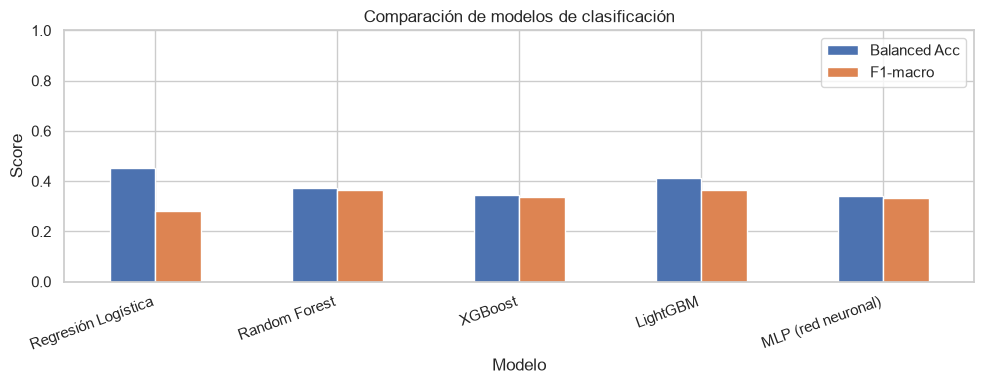

In [7]:
# Comparación visual de F1-macro y Balanced Accuracy
ax = tabla[['Balanced Acc', 'F1-macro']].plot.bar(figsize=(10, 4))
ax.set_title('Comparación de modelos de clasificación')
ax.set_ylabel('Score'); ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()

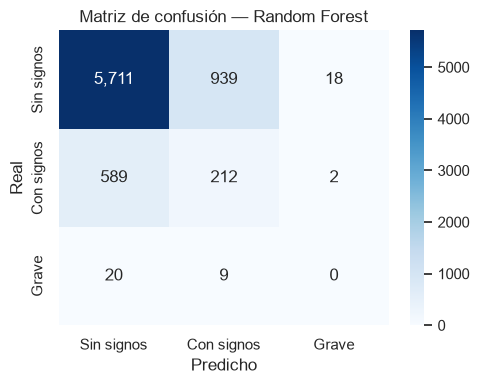

In [8]:
# Matriz de confusión del mejor modelo (por F1-macro)
mejor = tabla['F1-macro'].idxmax()
cm = matrices[mejor]
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['Sin signos','Con signos','Grave'],
            yticklabels=['Sin signos','Con signos','Grave'], ax=ax)
ax.set_title(f'Matriz de confusión — {mejor}')
ax.set_xlabel('Predicho'); ax.set_ylabel('Real'); plt.tight_layout(); plt.show()

## 5. ¿Es adecuado el dataset para CLASIFICACIÓN?

**Cómo decidirlo con las métricas:**
- Si el **F1-macro** y el **recall de *Grave*** son razonables (> ~0.4–0.5) → el dataset aporta señal.
- Si la accuracy es alta (~89 %) pero el F1-macro es bajo y el recall de *Grave* ≈ 0 → el modelo
  solo predice la clase mayoritaria: el dataset **no** tiene suficiente señal demográfica/geográfica
  para esta tarea (resultado igualmente válido para reportar en el informe).

> Escribir aquí la conclusión observada tras ejecutar las celdas.